#  Netflix Business Insights Dashboard


## Business questions we will answer

1. How has the catalogue grown, and **where does the content come from**?
2. **Who is the content made for** (mature, teen or family audiences)?
3. Can a model **predict the audience level** of a title from its details?
4. How many titles will be added **in the next few years**?
5. What should the business **do about it**?

## The 5 steps of this task

| Step | What we do | Where |
|------|-----------|-------|
| **1** | Complete data analysis (clean, explore, find insights) | `pandas`, `seaborn` |
| **2** | Develop predictive models (classification and forecasting) | `scikit-learn` |
| **3** | Create interactive visualizations (dashboard) | `plotly` |
| **4** | Generate business recommendations | evidence-based |
| **5** | Present findings in a professional report | this notebook + Word report |



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
NETFLIX_RED = "#E50914"      # our main colour
DARK = "#221F1F"             # our second colour

os.makedirs("figures", exist_ok=True)     # every chart will be saved here for the report


def save_fig(name):
    # Save the current chart as an image inside the 'figures' folder
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")

---
#  Complete Data Analysis



In [2]:
df = pd.read_csv("Dataset.csv")
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (8790, 10)


,oi,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


## 1.2 Clean and prepare the data

Good analysis starts with clean data. We will:

1. Turn the fake empty value `"Not Given"` into a proper missing value (then label it `"Unknown"`).
2. Convert `date_added` to a real date and extract the **year** and **month**.
3. Split `duration` into **movie minutes** and **TV seasons** (they are stored as text like `"90 min"` and `"2 Seasons"`).
4. Group the many `rating` labels into **3 easy audience groups**.
5. Calculate how many years passed between a title's release and the day it was added.

In [3]:
data = df.copy()

# 1. Missing values
data = data.replace("Not Given", np.nan)
data["director"] = data["director"].fillna("Unknown")
data["country"] = data["country"].fillna("Unknown")

# 2. Dates
data["date_added"] = pd.to_datetime(data["date_added"], format="%m/%d/%Y")
data["year_added"] = data["date_added"].dt.year
data["month_added"] = data["date_added"].dt.month

# 3. Duration: take the number out of the text, then split by type
data["duration_value"] = data["duration"].str.extract(r"(\d+)")[0].astype(int)
data["movie_minutes"] = np.where(data["type"] == "Movie", data["duration_value"], 0)
data["tv_seasons"] = np.where(data["type"] == "TV Show", data["duration_value"], 0)

# 4. Audience group from the rating
audience_map = {
    "TV-MA": "Mature", "R": "Mature", "NC-17": "Mature",
    "TV-14": "Teen", "PG-13": "Teen", "TV-PG": "Teen", "PG": "Teen",
    "TV-Y": "Family", "TV-Y7": "Family", "TV-Y7-FV": "Family", "TV-G": "Family", "G": "Family",
    "NR": "Unrated", "UR": "Unrated",
}
data["audience"] = data["rating"].map(audience_map)

# 5. Years between release and being added (a few are negative, so we set them to 0)
data["years_to_add"] = (data["year_added"] - data["release_year"]).clip(lower=0)

# Genres as a Python list, e.g. "Dramas, Comedies" -> ["Dramas", "Comedies"]
data["genres"] = data["listed_in"].str.split(", ")

print("Missing values left:", data[["type", "rating", "date_added", "duration", "audience"]].isnull().sum().sum())
data[["title", "type", "country", "year_added", "movie_minutes", "tv_seasons", "rating", "audience", "years_to_add"]].head()

Missing values left: 0


,title,type,country,year_added,movie_minutes,tv_seasons,rating,audience,years_to_add
0,Dick Johnson Is Dead,Movie,United States,2021,90,0,PG-13,Teen,1
1,Ganglands,TV Show,France,2021,0,1,TV-MA,Mature,0
2,Midnight Mass,TV Show,United States,2021,0,1,TV-MA,Mature,0
3,Confessions of an Invisible Girl,Movie,Brazil,2021,91,0,TV-PG,Teen,0
4,Sankofa,Movie,United States,2021,125,0,TV-MA,Mature,28


The mapping we used to group the ratings:

| Audience group | Ratings |
|----------------|---------|
| **Family** | TV-Y, TV-Y7, TV-Y7-FV, TV-G, G |
| **Teen** | TV-14, PG-13, TV-PG, PG |
| **Mature** | TV-MA, R, NC-17 |
| **Unrated** | NR, UR (we ignore these in the models) |

## 1.3 Key numbers at a glance

In [4]:
real_countries = data.loc[data["country"] != "Unknown", "country"]

kpis = {
    "Total titles":               f"{len(data):,}",
    "Movies":                     f"{(data['type'] == 'Movie').mean():.0%}",
    "TV Shows":                   f"{(data['type'] == 'TV Show').mean():.0%}",
    "Countries":                  f"{real_countries.nunique()}",
    "Mature content":             f"{(data['audience'] == 'Mature').mean():.0%}",
    "Median years release to add": f"{data['years_to_add'].median():.0f}",
}
pd.Series(kpis, name="Value").to_frame()

,Value
Total titles,"8,790"
Movies,70%
TV Shows,30%
Countries,85
Mature content,46%
Median years release to add,1


## 1.4 Explore the data

### Question 1: How has the catalogue grown?

type        Movie  TV Show  Total
year_added                       
2015           56       26     82
2016          251      175    426
2017          836      349   1185
2018         1237      411   1648
2019         1424      592   2016
2020         1284      595   1879
2021          993      505   1498


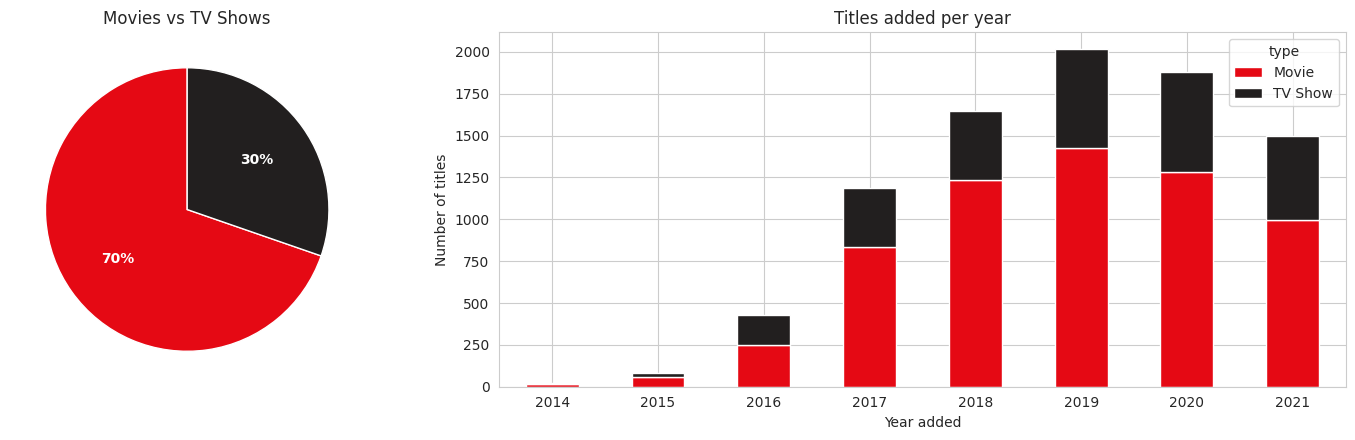

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 2]})

# Left: Movies vs TV Shows
type_counts = data["type"].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct="%1.0f%%",
            colors=[NETFLIX_RED, DARK], startangle=90, textprops={"color": "white", "fontweight": "bold"})
axes[0].set_title("Movies vs TV Shows")

# Right: titles added each year (from 2014 onwards, earlier years have very few titles)
yearly_type = data[data["year_added"] >= 2014].groupby(["year_added", "type"]).size().unstack(fill_value=0)
yearly_type.plot(kind="bar", stacked=True, ax=axes[1], color=[NETFLIX_RED, DARK])
axes[1].set_title("Titles added per year")
axes[1].set_xlabel("Year added")
axes[1].set_ylabel("Number of titles")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
save_fig("01_growth")
plt.show()

print(yearly_type.assign(Total=yearly_type.sum(axis=1)).tail(7))

**💡 What the charts tell us**

- The catalogue is **70% movies and 30% TV shows**.
- Yearly additions exploded from **426 titles in 2016 to a peak of 2,016 in 2019**, then eased to **1,879 in 2020** (down 7%). By September 2021 we already see 1,498 titles (about 2,040 if the pace continues for the full year).
- TV shows were 41% of additions in 2016, dropped to 25% in 2018 and have been climbing back since (**34% in 2021**).
- **The fast-growth phase is over.** The catalogue is no longer growing quickly each year. This matters for the forecast in Step 2.

### Question 2: Where does the content come from, and what kind is it?

Top 10 countries hold 75% of all titles
United States share : 36.9%


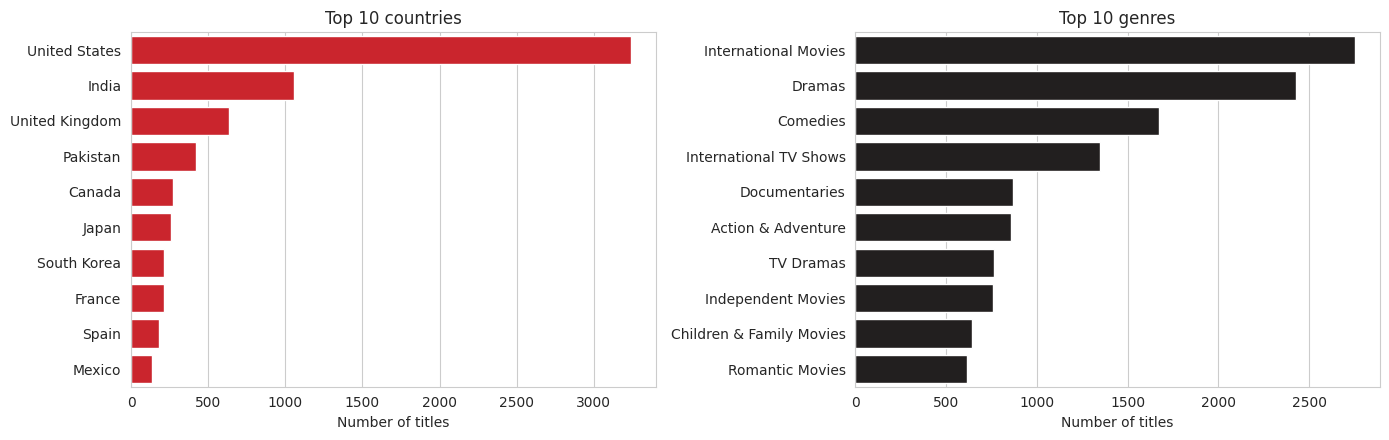

In [6]:
top_countries = real_countries.value_counts().head(10)
top_genres = data["genres"].explode().value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.barplot(x=top_countries.values, y=top_countries.index, color=NETFLIX_RED, ax=axes[0])
axes[0].set_title("Top 10 countries")
axes[0].set_xlabel("Number of titles")
axes[0].set_ylabel("")

sns.barplot(x=top_genres.values, y=top_genres.index, color=DARK, ax=axes[1])
axes[1].set_title("Top 10 genres")
axes[1].set_xlabel("Number of titles")
axes[1].set_ylabel("")

plt.tight_layout()
save_fig("02_countries_genres")
plt.show()

print("Top 10 countries hold", f"{top_countries.sum() / len(data):.0%}", "of all titles")
print("United States share :", f"{(data['country'] == 'United States').mean():.1%}")

**💡 What the charts tell us**

- The **United States** is the biggest source (3,240 titles, **36.9%**), but that means about **63% of the catalogue comes from outside the US**.
- **India** is second (1,057 titles, 12%), then the United Kingdom (638) and **Pakistan** (421, the 4th biggest).
- The top 10 countries together make **75%** of all titles.
- The leading genres are **International Movies** (2,752), **Dramas** (2,426) and **Comedies** (1,674). The many "International" labels confirm that this is a truly global catalogue.
- 287 titles (3%) have an unknown country.

### Question 3: Who is the content made for?

Overall audience mix (%):
audience
Mature    46.0
Teen      43.6
Family    10.4
Name: proportion, dtype: float64

Audience mix by year (%):
audience    Family  Teen  Mature
year_added                      
2016          16.3  39.3    44.4
2017           9.3  46.5    44.2
2018           8.2  44.1    47.7
2019           7.8  45.2    47.0
2020          12.1  42.2    45.7
2021          12.8  41.9    45.3


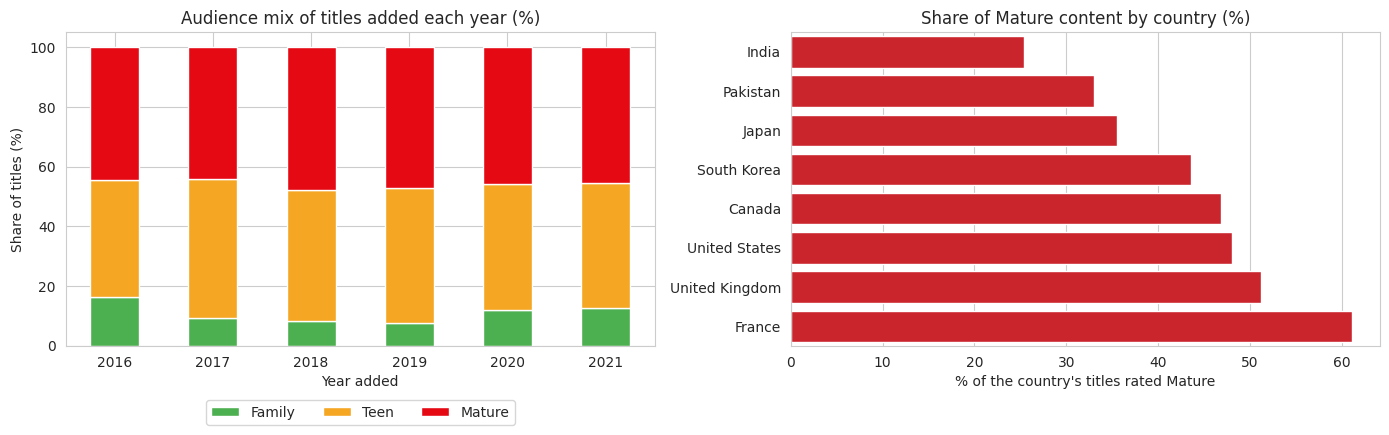

In [7]:
rated = data[data["audience"] != "Unrated"]

# Left: how the audience mix changed over the years (share in %)
aud_year = pd.crosstab(rated["year_added"], rated["audience"], normalize="index")[["Family", "Teen", "Mature"]] * 100
aud_year = aud_year.loc[2016:]

# Right: share of Mature content in the 8 biggest countries
top8 = real_countries.value_counts().head(8).index
mature_share = (rated[rated["country"].isin(top8)]
                .groupby("country")["audience"]
                .apply(lambda s: (s == "Mature").mean() * 100)
                .sort_values())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

aud_year.plot(kind="bar", stacked=True, ax=axes[0], color=["#4CAF50", "#F5A623", NETFLIX_RED])
axes[0].set_title("Audience mix of titles added each year (%)")
axes[0].set_xlabel("Year added")
axes[0].set_ylabel("Share of titles (%)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)

sns.barplot(x=mature_share.values, y=mature_share.index, color=NETFLIX_RED, ax=axes[1])
axes[1].set_title("Share of Mature content by country (%)")
axes[1].set_xlabel("% of the country's titles rated Mature")
axes[1].set_ylabel("")

plt.tight_layout()
save_fig("03_audience")
plt.show()

print("Overall audience mix (%):")
print((rated["audience"].value_counts(normalize=True) * 100).round(1))
print()
print("Audience mix by year (%):")
print(aud_year.round(1))

**💡 What the charts tell us**

- Overall, **46% of titles are Mature**, 44% are Teen and only **10% are Family**.
- The Family share **fell from 16.3% (2016) to 7.8% (2019)** and has recovered to **12.8% in 2021**.
- The audience mix depends strongly on the country: **France (61%)** and the **United Kingdom (51%)** have mostly Mature titles, while **India (25%)** and **Pakistan (33%)** have mostly Teen and Family titles.

### Question 4: How long are the movies and how many seasons do shows get?

Median movie length       : 98.0 minutes
TV shows with 1 season    : 67%
TV shows with 3+ seasons  : 17%

Average movie length by year added:
year_added
2015     83.6
2016     83.6
2017     95.7
2018    101.7
2019     99.9
2020    101.6
2021    102.8
Name: movie_minutes, dtype: float64


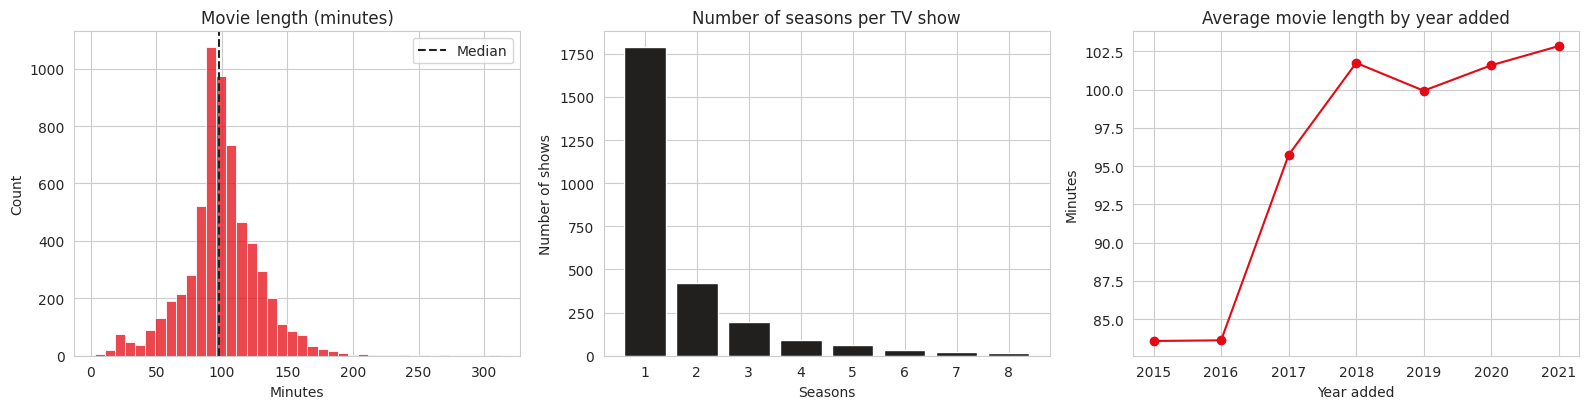

In [8]:
movies = data[data["type"] == "Movie"]
shows = data[data["type"] == "TV Show"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# Movie length distribution
sns.histplot(movies["movie_minutes"], bins=40, color=NETFLIX_RED, ax=axes[0])
axes[0].axvline(movies["movie_minutes"].median(), color=DARK, linestyle="--", label="Median")
axes[0].set_title("Movie length (minutes)")
axes[0].set_xlabel("Minutes")
axes[0].legend()

# Number of seasons per TV show
season_counts = shows["tv_seasons"].value_counts().sort_index().head(8)
axes[1].bar(season_counts.index.astype(str), season_counts.values, color=DARK)
axes[1].set_title("Number of seasons per TV show")
axes[1].set_xlabel("Seasons")
axes[1].set_ylabel("Number of shows")

# Average movie length by the year it was added
movie_len_year = movies[movies["year_added"] >= 2015].groupby("year_added")["movie_minutes"].mean()
axes[2].plot(movie_len_year.index, movie_len_year.values, marker="o", color=NETFLIX_RED)
axes[2].set_title("Average movie length by year added")
axes[2].set_xlabel("Year added")
axes[2].set_ylabel("Minutes")

plt.tight_layout()
save_fig("04_duration")
plt.show()

print("Median movie length       :", movies["movie_minutes"].median(), "minutes")
print("TV shows with 1 season    :", f"{(shows['tv_seasons'] == 1).mean():.0%}")
print("TV shows with 3+ seasons  :", f"{(shows['tv_seasons'] >= 3).mean():.0%}")
print()
print("Average movie length by year added:")
print(movie_len_year.round(1))

**💡 What the charts tell us**

- The typical movie lasts **98 minutes**. The average movie length **grew from about 84 minutes (2016) to about 103 minutes (2021)**.
- **67% of TV shows have just 1 season** and only **17% reach 3 or more seasons**. (Careful: many of these shows are recent and may still get a second season.)

---
# Step 2 – Develop Predictive Models

We build **two** predictive models that solve real business problems.

| Model | Business problem | Type of ML |
|-------|-----------------|------------|
| **A. Audience classifier** | Automatically tag the audience level of a title (Mature or not) from its details | Classification |
| **B. Catalogue forecast** | Estimate how many titles will be added in the next years | Forecasting (regression) |

---
## Model A – Predict if a title is for a Mature audience

**Why is this useful?** New titles often arrive without a clear audience tag. A model can suggest the tag automatically, help with parental controls and help decide where to promote a title.

**Rules to avoid cheating:** we do **not** use the `rating` column as an input, because it is what we are predicting.

### A1. Prepare the target and the input features

In [9]:
# Keep only titles with a clear audience group
ml = data[data["audience"] != "Unrated"].copy()

# TARGET: 1 = Mature, 0 = not Mature
ml["is_mature"] = (ml["audience"] == "Mature").astype(int)

# FEATURE: country. Keep the 12 biggest countries, put the rest in "Other"
big_countries = ml["country"].value_counts().head(12).index
ml["country_group"] = ml["country"].where(ml["country"].isin(big_countries), "Other")

# FEATURE: genres. One 0/1 column for each of the 25 most common genres
common_genres = data["genres"].explode().value_counts().head(25).index
genre_cols = pd.DataFrame(
    {"genre_" + g: ml["genres"].apply(lambda genre_list: int(g in genre_list)) for g in common_genres}
)

# Put all features together
X = pd.concat([
    ml[["release_year", "year_added", "movie_minutes", "tv_seasons"]],
    (ml["type"] == "Movie").astype(int).rename("is_movie"),
    pd.get_dummies(ml["country_group"], prefix="country").astype(int),
    genre_cols,
], axis=1)
y = ml["is_mature"]

print("Features (columns):", X.shape[1])
print("Titles (rows)     :", X.shape[0])
print()
print("Share of Mature titles:", f"{y.mean():.1%}")
X.head(3)

Features (columns): 43
Titles (rows)     : 8708

Share of Mature titles: 46.0%


,release_year,year_added,movie_minutes,tv_seasons,is_movie,country_Canada,country_Egypt,country_France,country_India,country_Japan,country_Mexico,country_Other,country_Pakistan,country_South Korea,country_Spain,country_United Kingdom,country_United States,country_Unknown,genre_International Movies,genre_Dramas,genre_Comedies,genre_International TV Shows,genre_Documentaries,genre_Action & Adventure,genre_TV Dramas,genre_Independent Movies,genre_Children & Family Movies,genre_Romantic Movies,genre_Thrillers,genre_TV Comedies,genre_Crime TV Shows,genre_Kids' TV,genre_Docuseries,genre_Music & Musicals,genre_Romantic TV Shows,genre_Horror Movies,genre_Stand-Up Comedy,genre_Reality TV,genre_British TV Shows,genre_Sci-Fi & Fantasy,genre_Sports Movies,genre_Anime Series,genre_Spanish-Language TV Shows
0,2020,2021,90,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2021,2021,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2021,2021,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### A2. Split into training and testing data

We hide 20% of the titles from the model. After training, we test it on these unseen titles. This shows how it would behave on **new** titles.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y      # stratify keeps the Mature share equal in both parts
)
print("Training titles:", len(X_train))
print("Testing titles :", len(X_test))

Training titles: 6966
Testing titles : 1742


### A3. Train and compare models

We compare 3 real models and 1 **baseline** (a dummy that always guesses the most common answer). A real model must beat the baseline to be useful.

| Model | Idea in one line |
|-------|-----------------|
| **Logistic Regression** | Simple and fast. Draws a straight boundary between the two groups. |
| **Random Forest** | Many decision trees vote together. |
| **Gradient Boosting** | Trees that learn from the mistakes of the previous trees. |

In [11]:
models = {
    "Baseline (always majority)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression":        make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest":              RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting":          GradientBoostingClassifier(random_state=42),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)                        # learn from training titles
    pred = model.predict(X_test)                       # predict the hidden titles
    proba = model.predict_proba(X_test)[:, 1]          # probability of being Mature
    cv = cross_val_score(model, X, y, cv=5).mean()     # 5-fold cross-validation: a second, more stable check

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "CV Accuracy (5-fold)": cv,
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Accuracy,Precision,Recall,F1,ROC-AUC,CV Accuracy (5-fold)
Model,,,,,,
Baseline (always majority),0.540,0.000,0.000,0.000,0.500,0.540
Logistic Regression,0.737,0.726,0.687,0.706,0.815,0.715
Random Forest,0.732,0.710,0.706,0.708,0.822,0.705
Gradient Boosting,0.749,0.729,0.723,0.726,0.829,0.701


**How to read the columns**

| Metric | Meaning |
|--------|---------|
| **Accuracy** | Out of 100 titles, how many did we label correctly? |
| **Precision** | When we say "Mature", how often are we right? |
| **Recall** | Out of all truly Mature titles, how many did we find? |
| **F1** | One number that balances precision and recall. |
| **ROC-AUC** | How well the model ranks Mature titles above others (0.5 = coin flip, 1.0 = perfect). |
| **CV Accuracy** | Average accuracy over 5 different train/test splits. It shows the result is not just luck. |

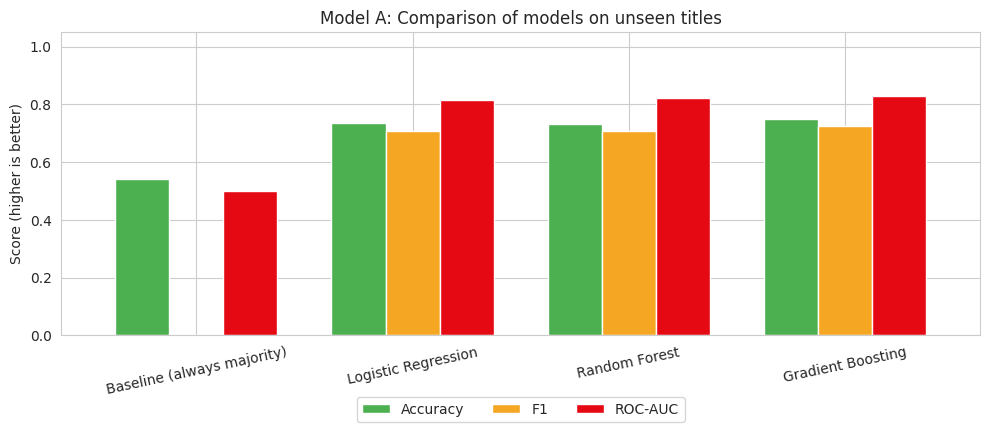

In [12]:
# Chart: compare the models
plot_data = results[["Accuracy", "F1", "ROC-AUC"]]
ax = plot_data.plot(kind="bar", figsize=(10, 4.5), width=0.75, color=["#4CAF50", "#F5A623", NETFLIX_RED])
ax.set_title("Model A: Comparison of models on unseen titles")
ax.set_ylabel("Score (higher is better)")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=12)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.tight_layout()
save_fig("05_model_comparison")
plt.show()

Best model: Gradient Boosting


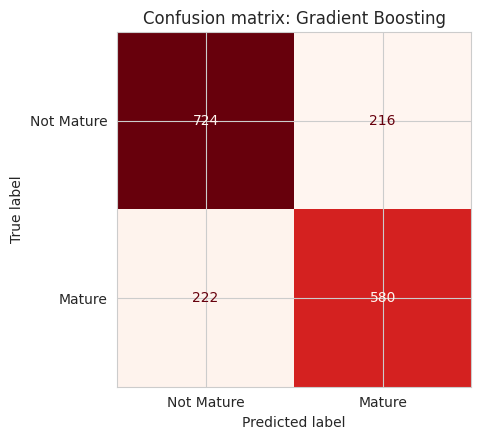

In [13]:
# Pick the best model by ROC-AUC (ignoring the baseline)
best_name = results.drop(index="Baseline (always majority)")["ROC-AUC"].idxmax()
best_model = models[best_name]
print("Best model:", best_name)

# Confusion matrix: where does the model get it right and wrong?
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,
                                      display_labels=["Not Mature", "Mature"],
                                      cmap="Reds", colorbar=False, ax=ax)
ax.set_title(f"Confusion matrix: {best_name}")
plt.tight_layout()
save_fig("06_confusion_matrix")
plt.show()

### A4. What drives the prediction?

Which features help the model the most? This turns the model from a "black box" into a **business insight**.

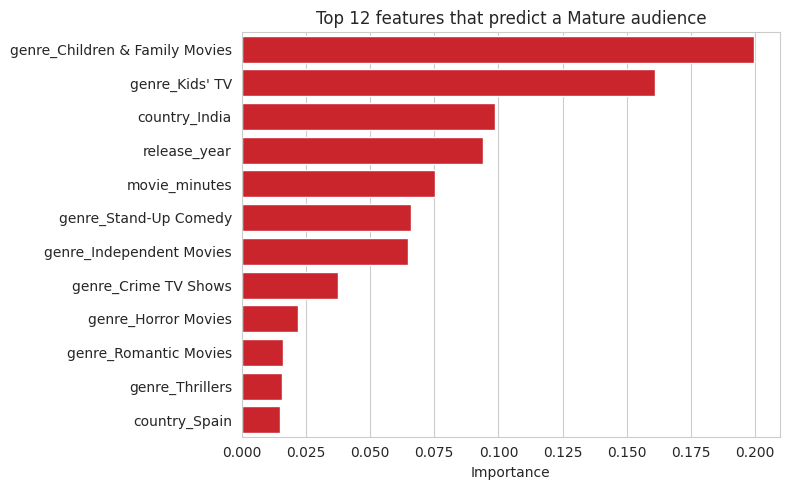

genre_Children & Family Movies    0.200
genre_Kids' TV                    0.161
country_India                     0.098
release_year                      0.094
movie_minutes                     0.075
genre_Stand-Up Comedy             0.066
genre_Independent Movies          0.065
genre_Crime TV Shows              0.038
genre_Horror Movies               0.022
genre_Romantic Movies             0.016
genre_Thrillers                   0.016
country_Spain                     0.015
dtype: float64

In [14]:
# Use the best model if it has importances, otherwise the Random Forest
tree_model = best_model if hasattr(best_model, "feature_importances_") else models["Random Forest"]

importance = pd.Series(tree_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index, color=NETFLIX_RED)
plt.title("Top 12 features that predict a Mature audience")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
save_fig("07_feature_importance")
plt.show()

importance.round(3)

**How well does the model work?**

- The **baseline** (always guess "Not Mature") is right **54%** of the time. Our three models reach **73% to 75% accuracy** and a ROC-AUC of **0.82 to 0.83**, about **20 points better** than guessing.
- **Gradient Boosting** is the best on the test titles (accuracy 74.9%, ROC-AUC 0.829). However, the three models are close, and the cross-validation puts Logistic Regression slightly ahead (71.5% vs 70.1%). The differences are small, so a simple model is almost as good.
- In the confusion matrix (1,742 test titles): **580 Mature titles were found correctly** and **724 Not Mature titles were correctly recognised**. There were 216 false alarms and 222 missed Mature titles.
- The strongest signals are the **family genres** (*Children & Family Movies* and *Kids' TV*), followed by the **country India** (we saw in Step 1 that only 25% of Indian titles are Mature), the **release year** and the **movie length**. *Stand-Up Comedy*, *Independent Movies* and *Crime TV Shows* also help.

* Be honest about the limits:** about 3 out of 4 predictions are correct. The model only sees basic details (genre, country, year, length) and not the story. So it is a good **assistant that suggests a tag for a human to check**, not something that should decide alone.

### Try the model on a real title

Let us ask the model about a few titles and compare with the real rating.

In [15]:
best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

check = ml.loc[X_test.index, ["title", "type", "listed_in", "rating"]].copy()
check["P(Mature)"] = best_proba.round(2)
check["Model says"] = np.where(best_pred == 1, "Mature", "Not Mature")
check["Truth"] = np.where(y_test == 1, "Mature", "Not Mature")

check.sample(8, random_state=3).reset_index(drop=True)

,title,type,listed_in,rating,P(Mature),Model says,Truth
0,Awake,Movie,"Dramas, Thrillers",TV-MA,0.67,Mature,Mature
1,Re:Mind,TV Show,"International TV Shows, TV Dramas, TV Mysteries",TV-MA,0.52,Mature,Mature
2,Secrets of Selfridges,Movie,Documentaries,TV-PG,0.21,Not Mature,Not Mature
3,Resurrection: Ertugrul,TV Show,"International TV Shows, TV Action & Adventure,...",TV-14,0.60,Mature,Not Mature
4,Kaabil,Movie,"Dramas, International Movies",TV-14,0.32,Not Mature,Not Mature
5,"Liar, Liar, Vampire",Movie,"Children & Family Movies, Comedies",TV-PG,0.03,Not Mature,Not Mature
6,The Bonfire of Destiny,TV Show,"International TV Shows, TV Dramas",TV-MA,0.74,Mature,Mature
7,Cosmic Sin,Movie,Action & Adventure,R,0.64,Mature,Mature


---
## Model B – Forecast how many titles will be added

**Why is this useful?** Content budgets, licensing and server planning all depend on how large the catalogue will be.

**Careful approach:** with only a few full years of data, a fancy model can easily mislead. So we test simple methods by pretending we are in the past (**backtesting**) and keep the one that would have worked best.

We use only **full years 2016 to 2020**. 2021 is incomplete (the data stops in September 2021).

In [16]:
yearly = data[data["year_added"].between(2016, 2020)].groupby("year_added").size()
print(yearly)

year_added
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
dtype: int64


### B1. Backtest three simple methods

For each test year (2018, 2019, 2020) we only give the method the years **before** it and check how close its guess is.

| Method | Idea |
|--------|------|
| **Same as last year** | Next year = this year |
| **Average of last 2 years** | Smooths out the noise |
| **Linear trend** | Draw a straight line through past years and continue it |

In [17]:
backtest_rows = []

for test_year in [2018, 2019, 2020]:
    past = yearly[yearly.index < test_year]          # only the years BEFORE the test year
    actual = yearly[test_year]

    # Method 1: same as last year
    guess_last = past.iloc[-1]

    # Method 2: average of the last 2 years
    guess_avg = past.tail(2).mean()

    # Method 3: straight-line trend
    line = LinearRegression().fit(past.index.values.reshape(-1, 1), past.values)
    guess_trend = line.predict([[test_year]])[0]

    backtest_rows.append({"Test year": test_year, "Actual": actual,
                          "Same as last year": guess_last,
                          "Average of last 2 years": guess_avg,
                          "Linear trend": guess_trend})

backtest = pd.DataFrame(backtest_rows).set_index("Test year").round(0)
print(backtest)

# Average error (in number of titles) of each method
methods = ["Same as last year", "Average of last 2 years", "Linear trend"]
errors = {m: (backtest[m] - backtest["Actual"]).abs().mean() for m in methods}
forecast_errors = pd.Series(errors, name="Average error (titles)").round(0).sort_values()
print()
forecast_errors

           Actual  Same as last year  Average of last 2 years  Linear trend
Test year                                                                  
2018         1648               1185                    806.0        1944.0
2019         2016               1648                   1416.0        2308.0
2020         1879               2016                   1832.0        2627.0


Same as last year          323.0
Linear trend               445.0
Average of last 2 years    496.0
Name: Average error (titles), dtype: float64

**What the backtest tells us**

- **"Same as last year"** had the smallest average error (**323 titles**), better than the linear trend (445) and the 2-year average (496).
- The linear trend **over-promised**: for 2020 it guessed 2,627 titles but the real number was 1,879. Growth had already slowed, and a straight line does not know that.
- With only 5 years of data, treat any forecast as a **range**, not an exact number.

## Forecast the next years

We show two scenarios so the business can see the range:

- **Plateau scenario** (main): the number stays at the 2020 level. This is the method with the smallest error in our backtest.
- **Trend scenario** (optimistic): the old straight-line growth continues.

We also compare with **2021 so far** (January to September), scaled up to a full year.

In [18]:
future_years = [2021, 2022, 2023]

# Plateau scenario: stays at the level of the last full year (the method that won our backtest)
plateau_level = yearly.iloc[-1]
plateau = pd.Series([plateau_level] * len(future_years), index=future_years)

# Trend scenario: straight line through all full years 2016-2020
line = LinearRegression().fit(yearly.index.values.reshape(-1, 1), yearly.values)
trend = pd.Series(line.predict(np.array(future_years).reshape(-1, 1)), index=future_years)

# 2021 so far, scaled up to a full year
last_date = data["date_added"].max()
days_passed = (last_date - pd.Timestamp("2021-01-01")).days + 1
titles_2021 = (data["year_added"] == 2021).sum()
annualised_2021 = titles_2021 * 365 / days_passed

print(f"Data ends on {last_date.date()}: {titles_2021:,} titles added in {days_passed} days of 2021")
print(f"2021 scaled to a full year: about {annualised_2021:,.0f} titles")
print()
print(pd.DataFrame({"Plateau scenario": plateau.round(0), "Trend scenario": trend.round(0)}))

Data ends on 2021-09-25: 1,498 titles added in 268 days of 2021
2021 scaled to a full year: about 2,040 titles

      Plateau scenario  Trend scenario
2021              1879          2552.0
2022              1879          2926.0
2023              1879          3299.0


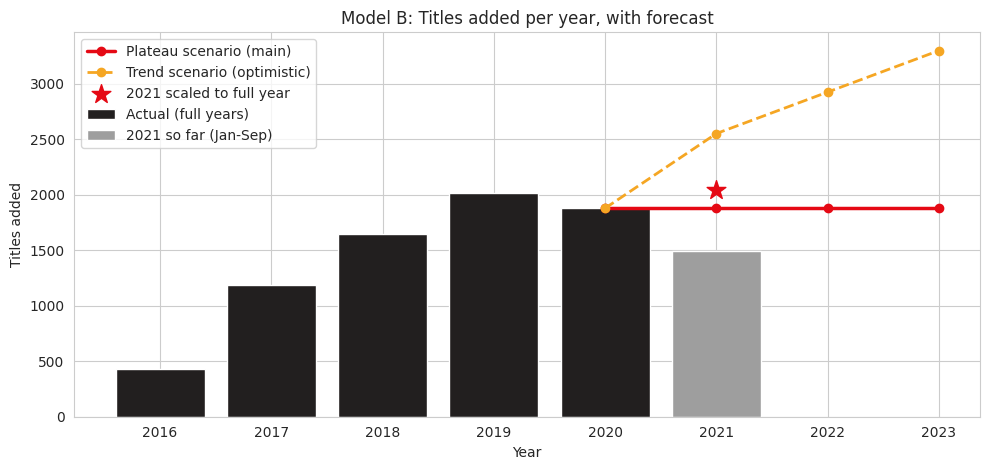

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(yearly.index, yearly.values, color=DARK, label="Actual (full years)")
ax.plot(2021, titles_2021, color="#9E9E9E", label="2021 so far (Jan-Sep)")
ax.plot([2020] + future_years, [yearly[2020]] + list(plateau.values), marker="o", color=NETFLIX_RED,
        linewidth=2.5, label="Plateau scenario (main)")
ax.plot([2020] + future_years, [yearly[2020]] + list(trend.values), marker="o", color="#F5A623",
        linestyle="--", linewidth=2, label="Trend scenario (optimistic)")
ax.scatter([2021], [annualised_2021], color=NETFLIX_RED, marker="*", s=200, zorder=5, label="2021 scaled to full year")

ax.set_title("Model B: Titles added per year, with forecast")
ax.set_xlabel("Year")
ax.set_ylabel("Titles added")
ax.set_xticks(list(yearly.index) + future_years)
ax.legend(loc="upper left")
plt.tight_layout()
save_fig("08_forecast")
plt.show()

**💡 What the forecast tells us**

- The **plateau scenario** says about **1,879 titles per year** from 2021 to 2023.
- 2021 is running slightly faster (about **2,040** for the full year, roughly 9% above), so a realistic planning range is **about 1,900 to 2,050 titles per year**.
- The optimistic trend scenario (up to about 3,300 titles in 2023) is **not supported** by the backtest, so we do not recommend planning on it.

---
# Step 3 – Create Interactive Visualizations

## 3a. One-page dashboard overview (image)

A dashboard puts the most important numbers and charts on **one page**. This static version is perfect for screenshots in your submission.

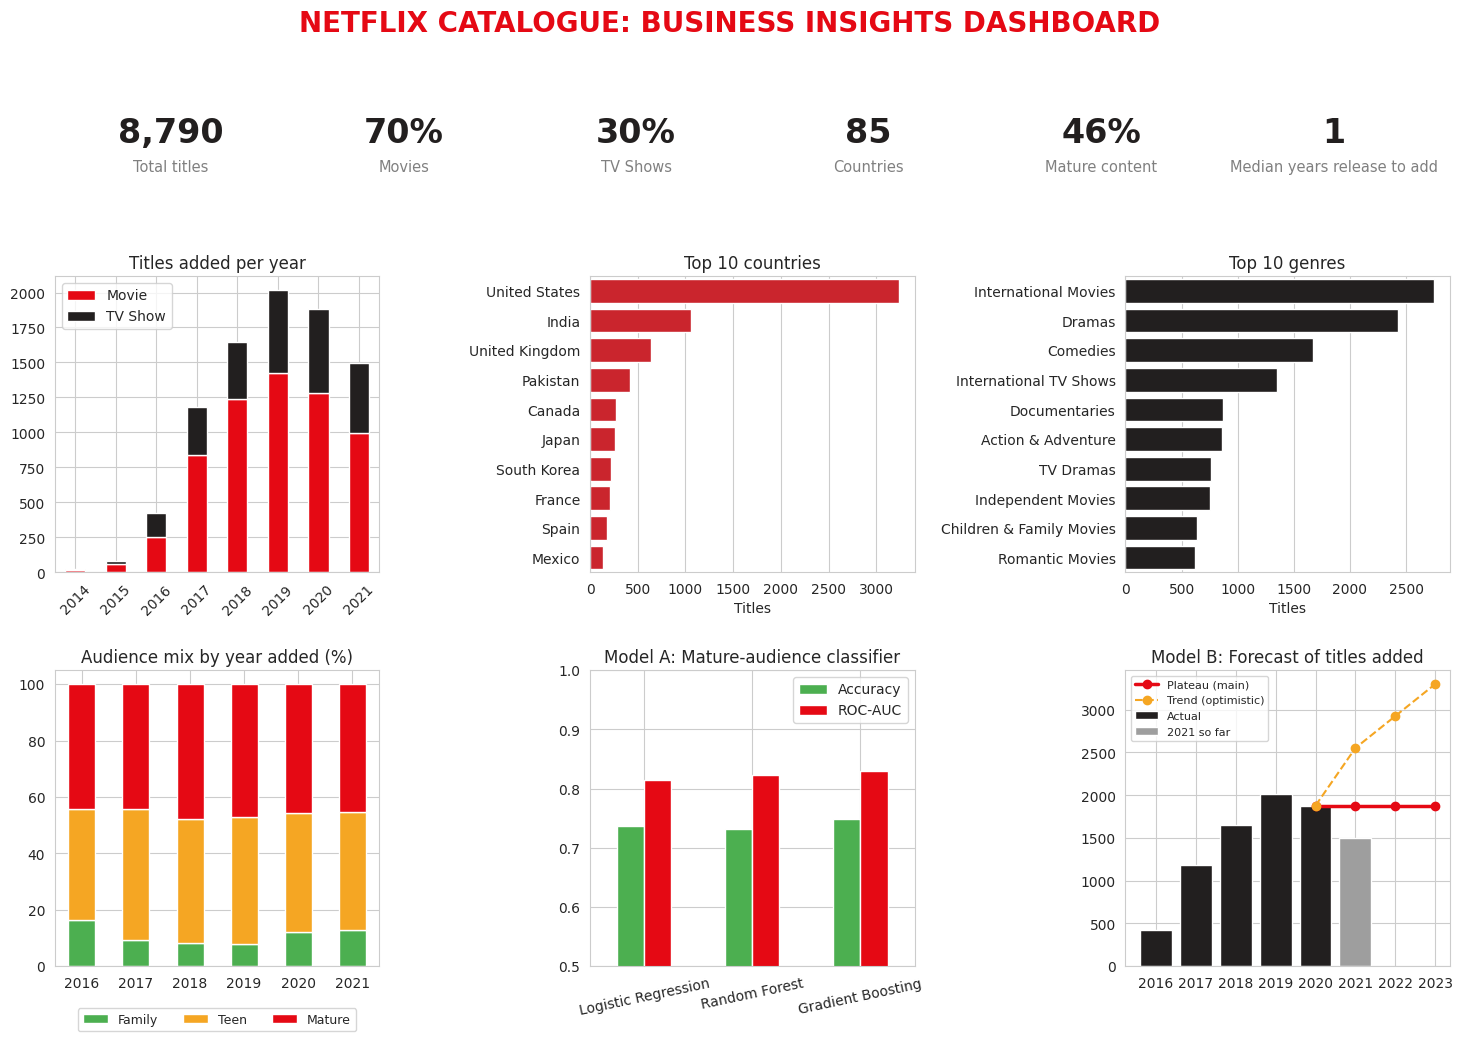

In [20]:
fig = plt.figure(figsize=(18, 11))
fig.suptitle("NETFLIX CATALOGUE: BUSINESS INSIGHTS DASHBOARD", fontsize=20, fontweight="bold", color=NETFLIX_RED, y=0.98)
grid = fig.add_gridspec(3, 3, height_ratios=[0.4, 2, 2], hspace=0.45, wspace=0.65)

# ---- Row 1: KPI cards
kpi_ax = fig.add_subplot(grid[0, :])
kpi_ax.axis("off")
for i, (label, value) in enumerate(kpis.items()):
    x = (i + 0.5) / len(kpis)
    kpi_ax.text(x, 0.62, value, fontsize=24, fontweight="bold", color=DARK, ha="center", transform=kpi_ax.transAxes)
    kpi_ax.text(x, 0.12, label, fontsize=10.5, color="gray", ha="center", transform=kpi_ax.transAxes)

# ---- Row 2
ax = fig.add_subplot(grid[1, 0])
yearly_type.plot(kind="bar", stacked=True, ax=ax, color=[NETFLIX_RED, DARK])
ax.set_title("Titles added per year"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=45)
ax.legend(title="", loc="upper left")

ax = fig.add_subplot(grid[1, 1])
sns.barplot(x=top_countries.values, y=top_countries.index, color=NETFLIX_RED, ax=ax)
ax.set_title("Top 10 countries"); ax.set_xlabel("Titles"); ax.set_ylabel("")

ax = fig.add_subplot(grid[1, 2])
sns.barplot(x=top_genres.values, y=top_genres.index, color=DARK, ax=ax)
ax.set_title("Top 10 genres"); ax.set_xlabel("Titles"); ax.set_ylabel("")

# ---- Row 3
ax = fig.add_subplot(grid[2, 0])
aud_year.plot(kind="bar", stacked=True, ax=ax, color=["#4CAF50", "#F5A623", NETFLIX_RED])
ax.set_title("Audience mix by year added (%)"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9)

ax = fig.add_subplot(grid[2, 1])
results.drop(index="Baseline (always majority)")[["Accuracy", "ROC-AUC"]].plot(kind="bar", ax=ax, color=["#4CAF50", NETFLIX_RED])
ax.set_title("Model A: Mature-audience classifier"); ax.set_xlabel(""); ax.set_ylim(0.5, 1.0)
ax.tick_params(axis="x", rotation=12)

ax = fig.add_subplot(grid[2, 2])
ax.bar(yearly.index, yearly.values, color=DARK, label="Actual")
ax.bar(2021, titles_2021, color="#9E9E9E", label="2021 so far")
ax.plot([2020] + future_years, [yearly[2020]] + list(plateau.values), marker="o", color=NETFLIX_RED, linewidth=2.5, label="Plateau (main)")
ax.plot([2020] + future_years, [yearly[2020]] + list(trend.values), marker="o", color="#F5A623", linestyle="--", label="Trend (optimistic)")
ax.set_title("Model B: Forecast of titles added"); ax.set_xticks(list(yearly.index) + future_years)
ax.legend(loc="upper left", fontsize=8)

save_fig("09_dashboard_overview")
plt.show()

## 3b. Interactive charts with Plotly

Now the charts become **interactive**: hover for exact numbers, zoom, click legend items to hide or show, and use the **dropdown menus** to filter by Movie / TV Show.

> ⚠️ Needs plotly. If you get an import error, run `pip install plotly` (or remove the `#` in the next cell).

In [ ]:
# !pip install plotly
import plotly.express as px
import plotly.graph_objects as go

RED_DARK_MAP = {"Movie": NETFLIX_RED, "TV Show": DARK}

### Chart 1 – Titles added per year (hover, zoom, click the legend)

In [ ]:
yearly_long = (data[data["year_added"] >= 2014]
               .groupby(["year_added", "type"]).size().reset_index(name="titles"))

fig1 = px.bar(yearly_long, x="year_added", y="titles", color="type", barmode="stack",
              color_discrete_map=RED_DARK_MAP, title="Titles added per year",
              labels={"year_added": "Year added", "titles": "Number of titles", "type": "Type"})
fig1.update_layout(template="plotly_white", height=430)
fig1.show()

### Chart 2 and 3 – Top genres and top countries (use the dropdown!)

We write one small helper function that builds a bar chart with a **dropdown** (All / Movie / TV Show).

In [ ]:
def bar_with_dropdown(views, title, x_title, color):
    # views = {"All": Series, "Movie": Series, "TV Show": Series}
    fig = go.Figure()
    names = list(views.keys())

    # One bar chart (trace) per view. Only the first one is visible at the start.
    for i, name in enumerate(names):
        s = views[name]
        fig.add_trace(go.Bar(x=list(s.values[::-1]), y=list(s.index[::-1]), orientation="h",
                             marker_color=color, name=name, visible=(i == 0)))

    # One button per view: it shows its own chart and hides the others
    buttons = []
    for i, name in enumerate(names):
        show = [j == i for j in range(len(names))]
        buttons.append(dict(label=name, method="update", args=[{"visible": show}]))

    fig.update_layout(title=title, xaxis_title=x_title, template="plotly_white", height=430,
                      showlegend=False,
                      updatemenus=[dict(buttons=buttons, direction="down", x=1.0, xanchor="right", y=1.18)])
    return fig


def top_genres_of(subset):
    return subset["genres"].explode().value_counts().head(10)

def top_countries_of(subset):
    return subset.loc[subset["country"] != "Unknown", "country"].value_counts().head(10)


movie_data = data[data["type"] == "Movie"]
tv_data = data[data["type"] == "TV Show"]

fig2 = bar_with_dropdown(
    {"All": top_genres_of(data), "Movie": top_genres_of(movie_data), "TV Show": top_genres_of(tv_data)},
    "Top 10 genres", "Number of titles", DARK)
fig2.show()

In [ ]:
fig3 = bar_with_dropdown(
    {"All": top_countries_of(data), "Movie": top_countries_of(movie_data), "TV Show": top_countries_of(tv_data)},
    "Top 10 countries", "Number of titles", NETFLIX_RED)
fig3.show()

### Chart 4 – Where in the world? (map)

In [ ]:
map_data = real_countries.value_counts().reset_index()
map_data.columns = ["country", "titles"]

fig4 = px.choropleth(map_data, locations="country", locationmode="country names",
                     color="titles", color_continuous_scale="Reds",
                     title="Number of titles by country of origin")
fig4.update_layout(height=470, margin=dict(l=0, r=0, t=50, b=0))
fig4.show()

### Chart 5 – Audience mix over the years

In [ ]:
aud_long = aud_year.reset_index().melt(id_vars="year_added", var_name="audience", value_name="share")

fig5 = px.bar(aud_long, x="year_added", y="share", color="audience", barmode="stack",
              color_discrete_map={"Family": "#4CAF50", "Teen": "#F5A623", "Mature": NETFLIX_RED},
              title="Audience mix of titles added each year (%)",
              labels={"year_added": "Year added", "share": "Share of titles (%)", "audience": "Audience"})
fig5.update_layout(template="plotly_white", height=430)
fig5.show()

### Chart 6 – Movie length

In [ ]:
fig6 = px.histogram(movies, x="movie_minutes", nbins=45, color_discrete_sequence=[NETFLIX_RED],
                    title="Movie length (minutes)", labels={"movie_minutes": "Minutes"})
fig6.update_layout(template="plotly_white", height=400, yaxis_title="Number of movies")
fig6.show()

### Chart 7 – Model results and forecast

In [ ]:
model_plot = results.drop(index="Baseline (always majority)").reset_index()
model_long = model_plot.melt(id_vars="Model", value_vars=["Accuracy", "F1", "ROC-AUC"],
                             var_name="Metric", value_name="Score")

fig7 = px.bar(model_long, x="Model", y="Score", color="Metric", barmode="group",
              title="Model A: Mature-audience classifier",
              color_discrete_sequence=["#4CAF50", "#F5A623", NETFLIX_RED])
fig7.update_layout(template="plotly_white", height=420, yaxis_range=[0, 1])
fig7.show()

In [ ]:
fig8 = go.Figure()
fig8.add_trace(go.Bar(x=list(yearly.index), y=list(yearly.values), name="Actual (full years)", marker_color=DARK))
fig8.add_trace(go.Bar(x=[2021], y=[titles_2021], name="2021 so far (Jan-Sep)", marker_color="#9E9E9E"))
fig8.add_trace(go.Scatter(x=[2020] + future_years, y=[yearly[2020]] + list(plateau.values),
                          mode="lines+markers", name="Plateau scenario (main)", line=dict(color=NETFLIX_RED, width=3)))
fig8.add_trace(go.Scatter(x=[2020] + future_years, y=[yearly[2020]] + list(trend.values),
                          mode="lines+markers", name="Trend scenario (optimistic)", line=dict(color="#F5A623", dash="dash")))
fig8.update_layout(title="Model B: Titles added per year, with forecast", template="plotly_white", height=430,
                   xaxis_title="Year", yaxis_title="Titles added")
fig8.show()

## 3c. Save everything as one dashboard web page

We combine the KPI cards and all interactive charts into **one HTML file**. Double-click it to open it in any browser and share it with your team.

In [ ]:
# Change to True if you want the file to work without internet (the file becomes about 4 MB bigger)
PLOTLY_JS = "cdn"

all_charts = [fig1, fig2, fig3, fig4, fig5, fig6, fig7, fig8]

# KPI cards
kpi_html = ""
for label, value in kpis.items():
    kpi_html += f'<div class="kpi"><div class="num">{value}</div><div class="lbl">{label}</div></div>'

# Charts: the plotly library is loaded only once (with the first chart)
charts_html = ""
for i, chart in enumerate(all_charts):
    include_js = PLOTLY_JS if i == 0 else False
    charts_html += '<div class="card">' + chart.to_html(full_html=False, include_plotlyjs=include_js) + '</div>'

PAGE = '''<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Netflix Business Insights Dashboard</title>
<style>
  body  { font-family: Arial, sans-serif; background: #f4f4f4; margin: 0; padding: 20px; }
  h1    { color: #E50914; text-align: center; margin-bottom: 5px; }
  .sub  { text-align: center; color: #666; margin-bottom: 25px; }
  .kpis { display: flex; flex-wrap: wrap; gap: 15px; justify-content: center; margin-bottom: 25px; }
  .kpi  { background: white; border-top: 4px solid #E50914; border-radius: 8px; padding: 15px 25px; text-align: center; min-width: 140px; }
  .num  { font-size: 30px; font-weight: bold; color: #221F1F; }
  .lbl  { font-size: 13px; color: #777; }
  .grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(480px, 1fr)); gap: 20px; }
  .card { background: white; border-radius: 8px; padding: 10px; box-shadow: 0 1px 4px rgba(0,0,0,0.15); }
</style>
</head>
<body>
  <h1>Netflix Business Insights Dashboard</h1>
  <div class="sub">Auspify Technologies - Data Science Internship - Task 6</div>
  <div class="kpis">@@KPIS@@</div>
  <div class="grid">@@CHARTS@@</div>
</body>
</html>'''

page = PAGE.replace("@@KPIS@@", kpi_html).replace("@@CHARTS@@", charts_html)

with open("netflix_dashboard.html", "w", encoding="utf-8") as f:
    f.write(page)

print("Saved: netflix_dashboard.html  (open it in your browser)")

---
# Step 4 – Generate Business Recommendations

Every recommendation below is linked to **evidence** from our analysis and models.

| # | What the data shows | Recommendation | How to measure success |
|---|--------------------|----------------|------------------------|
| **1** | Additions peaked at **2,016 in 2019** and then flattened. The forecast is **about 1,900 to 2,050 per year**. | **Move from "more titles" to "better titles".** Plan the budget around roughly 2,000 titles a year and grow through quality, not volume. | Engagement per title, cost per hour watched |
| **2** | **63% of titles come from outside the US.** India is #2 (12%) and Pakistan is #4 (421 titles). | **Keep investing in local content in South Asia** and test promoting the best regional titles to neighbouring countries. | Viewing hours of regional titles, new sign-ups in those regions |
| **3** | **Family content is only 10%** of the catalogue. It fell to 7.8% in 2019 and recovered to 12.8% in 2021. | **Keep growing the Family share** (for example towards 15%) and test if it improves household retention. | Retention of households with children, family-title engagement |
| **4** | **67% of TV shows have only 1 season** and only 17% reach 3+ seasons. TV is 34% of new additions in 2021. | **Use engagement data to decide early which shows to renew**, and avoid too many "one-season" shows. | Season-2 renewal rate, viewing per season |
| **5** | **46% of titles are Mature**, and the share varies from **25% (India) to 61% (France)**. Our model predicts Mature vs not with **about 75% accuracy**. | **Use the model as an assistant** to suggest audience tags for new or untagged titles. A person reviews the suggestion. Also use it for parental controls and targeted promotion. | Time saved on tagging, share of correct tags after review |
| **6** | **29% of directors and 3% of countries are missing**, and some values look wrong (for example *Squid Game* is listed with Pakistan as the country). | **Improve the metadata**: fix errors and add plot descriptions and cast. Better data will improve both the recommendations and the models. | Share of complete records, model accuracy after adding new fields |

### Important limits of these recommendations

- Our data describes **what is in the catalogue**, not **how much people watch it**. So these are **well-supported hypotheses to test** (for example with A/B tests), not guaranteed results.
- The forecast is based on only 5 full years and should be updated every quarter.

---
# Step 5 – Present Findings (Executive Report)

The full formatted report is provided as a separate Word file (**Netflix_Business_Insights_Report.docx**). Here is the summary.

### Headline findings

1. **Growth has plateaued.** Additions peaked in 2019 (2,016 titles). Expect about **1,900 to 2,050 titles per year** ahead.
2. **The catalogue is global.** 63% of titles come from outside the US, and the top 10 countries make up 75%.
3. **Mature content dominates** (46%) while **Family content is only 10%**, with big differences between countries.
4. **Audience level can be predicted** from basic details with **about 75% accuracy** (baseline 54%), enough to assist human taggers.
5. **Most TV shows (67%) have only 1 season.**

### Files delivered with this project

| File | What it is |
|------|-----------|
| `Netflix_Business_Insights_Dashboard.ipynb` | This notebook (full code and outputs) |
| `Netflix_Business_Insights_Report.docx` | Professional report for decision makers |
| `netflix_dashboard.html` | Interactive dashboard (created when you run Step 3c) |
| `figures/` | All charts as images (for screenshots and reports) |

In [31]:
# A live summary: these numbers come straight from the data, so they always match the notebook
best_row = results.loc[best_name]

print("=" * 62)
print("EXECUTIVE SUMMARY")
print("=" * 62)
print(f"Catalogue size            : {len(data):,} titles ({(data['type'] == 'Movie').mean():.0%} movies, {(data['type'] == 'TV Show').mean():.0%} TV shows)")
print(f"Countries of origin       : {real_countries.nunique()} (top 10 = {top_countries.sum() / len(data):.0%} of titles)")
print(f"Mature content            : {(rated['audience'] == 'Mature').mean():.0%} of rated titles vs Family {(rated['audience'] == 'Family').mean():.0%}")
print(f"Best audience model       : {best_name} (accuracy {best_row['Accuracy']:.0%}, ROC-AUC {best_row['ROC-AUC']:.2f})")
print(f"Best forecasting method   : {forecast_errors.index[0]} (average error {forecast_errors.iloc[0]:,.0f} titles)")
print(f"Forecast (plateau)        : about {plateau_level:,.0f} titles added per year")
print("=" * 62)

EXECUTIVE SUMMARY
Catalogue size            : 8,790 titles (70% movies, 30% TV shows)
Countries of origin       : 85 (top 10 = 75% of titles)
Mature content            : 46% of rated titles vs Family 10%
Best audience model       : Gradient Boosting (accuracy 75%, ROC-AUC 0.83)
Best forecasting method   : Same as last year (average error 323 titles)
Forecast (plateau)        : about 1,879 titles added per year


In [32]:
print("Charts saved for the report:")
for file in sorted(os.listdir("figures")):
    print(" -", file)

Charts saved for the report:
 - 01_growth.png
 - 02_countries_genres.png
 - 03_audience.png
 - 04_duration.png
 - 05_model_comparison.png
 - 06_confusion_matrix.png
 - 07_feature_importance.png
 - 08_forecast.png
 - 09_dashboard_overview.png


---
# ✅ Conclusion

We completed an end-to-end data science project:

1. **Analysis:** cleaned the data and answered four business questions with charts.
2. **Models:** built a classifier (audience level) and a forecast (catalogue additions), and tested both honestly against baselines.
3. **Dashboard:** created a one-page image dashboard and an interactive Plotly dashboard (`netflix_dashboard.html`).
4. **Recommendations:** turned the findings into concrete actions.
5. **Report:** summarised everything for decision makers.

**Ideas to go further**

- Add plot descriptions to improve the audience model.
- Add viewing data (watch time, ratings) to measure real performance.
- Combine this project with the recommendation system from Task 3.

---
*#Auspify #AuspifyTechnologies #AuspifyInternship #AuspifyProjects*